# AP 155 Lab Exercise
---
## Exercise 5: Matrices

_Instructions_: 
- **Report figure:** Plot of voltage for each node. 
- **Report discussion:**
  - What were the basis linear equations used to set up the matrix in each question of Problem 2?
  - Once you set up the matrices, what function did you use to solve the matrix equation (Could have different answers)? Check the docstring/documentation/other references and summarize the mechanism behind the function 
- **Code**: Complete the code and ensure it is functional, error-free, readable, and efficient (where needed). Include concise Markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Last Name, First Name)_: Agbay, Tristan Michael
- _Student No._: 2024-00281
- _Section_: THU-WX-1

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1BMSlPot2Mc7XLu0eo4S8I8gLBsIadbCL/view?usp=sharing) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

<!-- ### Report figure

<img src="figures/cat.jpg" alt="Alt text" width=45%> <img src="figures/cat.jpg" alt="Alt text" width=45%>


EDIT ME. See instruction above for what to include. Insert caption here, a short description what the figure illustrates. The syntax in markdown for putting a figure is `![Description](local_file_name.png)` or `<img src="/path/to_image.jpg" alt="Alt text" width=45%>`. Make sure the figure has complete elements.
-->

### Report figure
![Figure 2](V_vs_n.png) 



Figure 1 shows the distribution of internal node voltages $V_i$ as a function of node position for resistor ladder networks of varying total size ($N = 10, 100, 500, 1000, 5000,$ and $10,000$).   



### Report discussion

  - What were the basis linear equations used to set up the matrix in each question of Problem 2?

The system of linear equations is derived by applying Kirchhoff's Current Law ($\sum I = 0$) and Ohm's Law ($I = \frac{\Delta V}{R}$) at each internal junction node $i$, assuming all resistors have equal resistance $R$:

First Node ($i = 1$):$$3V_1 - V_2 - V_3 = V_+$$Second Node ($i = 2$):$$-V_1 + 4V_2 - V_3 - V_4 = V_+$$General Interior Nodes ($3 \le i \le N-2$):$$-V_{i-2} - V_{i-1} + 4V_i - V_{i+1} - V_{i+2} = 0$$Penultimate Node ($i = N-1$):$$-V_{N-3} - V_{N-2} + 4V_{N-1} - V_N = V_- = 0$$Final Node ($i = N$):$$-V_{N-2} - V_{N-1} + 3V_N = V_- = 0$$

  
  
  - Once you set up the matrices, what function did you use to solve the matrix equation (Could have different answers)? Check the docstring/documentation/other references and summarize the mechanism behind the function 

The function I used to solve the matrix equation was `np.linalg.solve()` for $N \le 100$. It factorizes matrix $\mathbf{A}$ using LU decomposition with partial pivoting ($\mathbf{A} = \mathbf{P}\mathbf{L}\mathbf{U}$) and then performs forward and backward substitution. And then I used a custom function, `banded(A, w, 2, 2)` which I used for $N \ge 1000$ that I adapted from Newman’s source. This function takes advantage of the matrix structure having non-zero values limited to 5 diagonals (2 upper, 2 lower, 1 main). The matrix is stored compactly in a $5 \times N$ shape, and Gaussian elimination is performed only within the non-zero band width.



### Other comments
- fun


---
## Section 2: Code

### Problem 1: (Newman 6.7) Resistor Ladder

**READ THE INSTRUCTIONS COMPLETELY**

Consider a long chain of resistors wired up like this:

<img src="reschain.png" alt="Alt text" width="95%">

All the resistors have the same resistance $R$.  The power rail at the top is at voltage $V_+=5$V.  The problem is to find the voltages $V_1, \ldots, V_N$ at the internal nodes in the circuit.

1. **Using Ohm's law and the Kirchhoff current law**, which says that the total net current flow out of (or into) any junction in a circuit must be zero, show that the voltages $V_1\ldots V_N$ satisfy the equations

$$3V_1 - V_2 - V_3 = V_+ $$
$$-V_1 + 4V_2 - V_3 - V_4 = V_+ $$
$$\cdots$$
$$-V_{i-2} - V_{i-1} + 4V_i - V_{i+1} - V_{i+2} = 0 $$
$$\cdots$$
$$-V_{N-3} - V_{N-2} + 4V_{N-1} - V_N = V_- = 0 $$
$$-V_{N-2} - V_{N-1} + 3V_N = V_- = 0 $$

Note: The assignment of $V_-$ is to make the equations symmetric

2. Express these equations in vector form $A\vec{v} = \vec{w}$ and find the values of the matrix $A$ and the vector $\vec{w}$.

3. Write a program to solve for the values of the $V_i$ when there are $N=6$ internal junctions with unknown voltages. (Hint: All the values of $V_i$ should lie between zero and $5$V.  If they don't, something is wrong.)

4. Now repeat your calculation for the case where there are $N=10\,000$ internal junctions.  This part is not possible using standard tools like the `np.linalg.solve` function.  You need to make use of the fact that the matrix $\vec{A}$ is banded, and uses `banded.py` by Mark Newman which can be obtained from the link: https://public.websites.umich.edu/~mejn/cp/programs.html

5. Plot your voltages in a histogram, make different histograms for varying number of nodes

In [27]:
import matplotlib.pyplot as plt
import numpy as np
from numpy import copy

# 2 and 3
A_6 = np.array([
    [3.0, -1.0, -1.0, 0.0, 0.0, 0.0],
    [-1.0, 4.0, -1.0, -1.0, 0.0, 0.0],
    [-1.0, -1.0, 4.0, -1.0, -1.0, 0.0],
    [0.0, -1.0, -1.0, 4.0, -1.0, -1.0],
    [0.0, 0.0, -1.0, -1.0, 4.0, -1.0],
    [0.0, 0.0, 0.0, -1.0, -1.0, 3.0],
])
w_6 = np.array([5.0, 5.0, 0.0, 0.0, 0.0, 0.0])

v_6 = np.linalg.solve(A_6, w_6)
print("Voltages for N = 6")
print(v_6)

Voltages for N = 6
[3.7254902  3.43137255 2.74509804 2.25490196 1.56862745 1.2745098 ]


In [28]:
#test practice - matrices

def build_full_matrix(N):
  A = np.zeros((N, N))

  # Main diagonal
  np.fill_diagonal(A, 4.0)
  A[0, 0] = 3.0
  A[-1, -1] = 3.0

  # First upper and lower sub-diagonals
  for i in range(N - 1):
    A[i, i + 1] = -1.0
    A[i + 1, i] = -1.0

  # Second upper and lower sub-diagonals
  for i in range(N - 2):
    A[i, i + 2] = -1.0
    A[i + 2, i] = -1.0

  # Vector w
  w = np.zeros(N)
  w[0] = 5.0
  w[1] = 5.0

  return A, w


#N = 10
A_10, w_10 = build_full_matrix(10)
v_10 = np.linalg.solve(A_10, w_10)


print("matrix for N = 10:\n", A_10)
print("Voltages (N=10):\n", v_10)

matrix for N = 10:
 [[ 3. -1. -1.  0.  0.  0.  0.  0.  0.  0.]
 [-1.  4. -1. -1.  0.  0.  0.  0.  0.  0.]
 [-1. -1.  4. -1. -1.  0.  0.  0.  0.  0.]
 [ 0. -1. -1.  4. -1. -1.  0.  0.  0.  0.]
 [ 0.  0. -1. -1.  4. -1. -1.  0.  0.  0.]
 [ 0.  0.  0. -1. -1.  4. -1. -1.  0.  0.]
 [ 0.  0.  0.  0. -1. -1.  4. -1. -1.  0.]
 [ 0.  0.  0.  0.  0. -1. -1.  4. -1. -1.]
 [ 0.  0.  0.  0.  0.  0. -1. -1.  4. -1.]
 [ 0.  0.  0.  0.  0.  0.  0. -1. -1.  3.]]
Voltages (N=10):
 [4.12573674 3.9194499  3.45776031 3.09430255 2.69155206 2.30844794
 1.90569745 1.54223969 1.0805501  0.87426326]


In [29]:
#N = 100 (practice)
A_100, w_100 = build_full_matrix(100)
v_100 = np.linalg.solve(A_100, w_100)

print("\nMatrix for N = 100")
print("First 5 voltages (N=100):", v_100[:5])


Matrix for N = 100
First 5 voltages (N=100): [4.89123004 4.86555293 4.80813718 4.76284451 4.71292124]


In [30]:
# Banded matrix solver adapted from Newman
# 4
def banded(Aa, va, up, down):
  # Copy the inputs and determine the size of the system
  A = copy(Aa)
  v = copy(va)
  N = len(v)

  # Gaussian elimination
  for m in range(N):

    # Normalization factor
    div = A[up, m]

    # Update the vector first
    v[m] /= div
    for k in range(1, down + 1):
      if m + k < N:
        v[m + k] -= A[up + k, m] * v[m]

    # Now normalize the pivot row of A and subtract from lower ones
    for i in range(up):
      j = m + up - i
      if j < N:
        A[i, j] /= div
        for k in range(1, down + 1):
          A[i + k, j] -= A[up + k, m] * A[i, j]

  # Backsubstitution
  for m in range(N - 2, -1, -1):
    for i in range(up):
      j = m + up - i
      if j < N:
        v[m] -= A[i, j] * v[j]

  return v

In [31]:
# 4: N = 10000 using banded solver
N_large = 10000

# 5xN banded matrix representation
A_large = np.zeros((5, N_large))
A_large[2, :] = 4
A_large[2, 0] = 3
A_large[2, -1] = 3
A_large[1, 1:] = -1
A_large[3, :-1] = -1
A_large[0, 2:] = -1
A_large[4, :-2] = -1

# Set up vector w
w_large = np.zeros(N_large)
w_large[0] = 5
w_large[1] = 5

# Solve for N = 10000 
v_large = banded(A_large, w_large, 2, 2)

print("\nfor N = 10,000")
print("First 5 voltages:", v_large[:5])
print("Last 5 voltages: ", v_large[-5:])


for N = 10,000
First 5 voltages: [4.99888228 4.99861842 4.99802841 4.99756299 4.99704997]
Last 5 voltages:  [0.00295003 0.00243701 0.00197159 0.00138158 0.00111772]


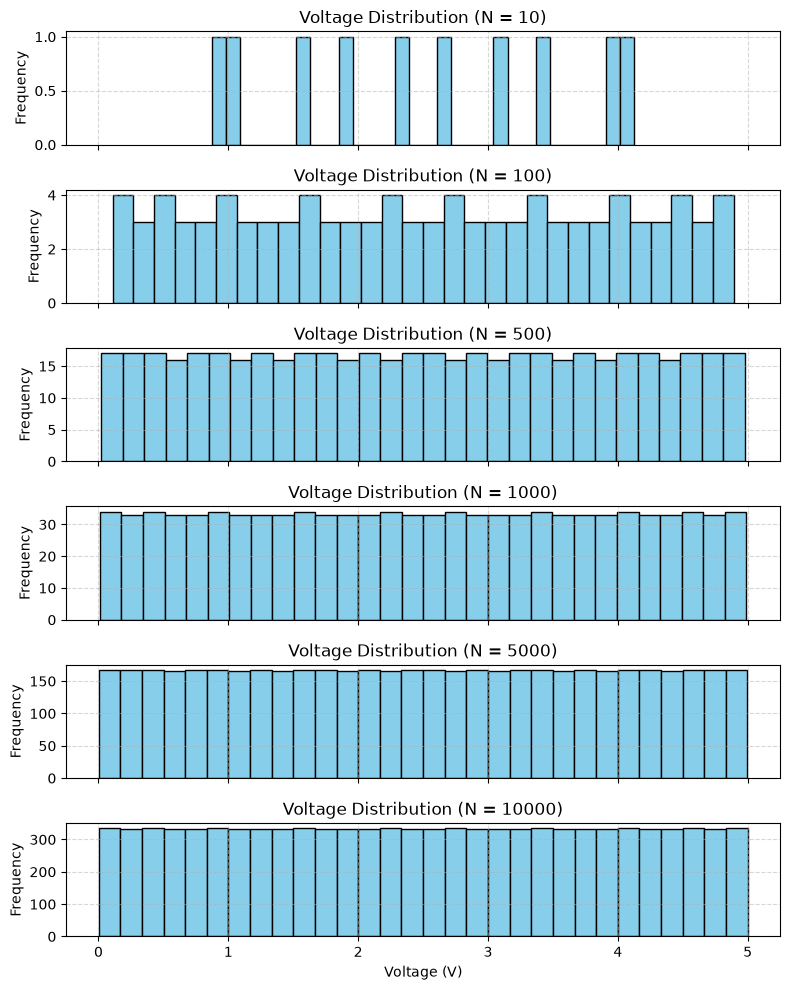

In [38]:
# 2 plots (histogram to show frequency, then a linear plot V vs N

N_values = [10, 100, 500, 1000, 5000, 10000]

# Create subplots for each value of N
fig, axes = plt.subplots(len(N_values), 1, figsize=(8, 10), sharex=True)

for ax, n_nodes in zip(axes, N_values):
  # Construct banded matrix A for the current system size
  A_temp = np.zeros((5, n_nodes))
  A_temp[2, :] = 4
  A_temp[2, 0] = 3
  A_temp[2, -1] = 3
  A_temp[1, 1:] = -1
  A_temp[3, :-1] = -1
  A_temp[0, 2:] = -1
  A_temp[4, :-2] = -1

  # Construct vector w
  w_temp = np.zeros(n_nodes)
  w_temp[0] = 5
  w_temp[1] = 5

  # Solve system using Newman's banded algorithm
  v_sol = banded(A_temp, w_temp, 2, 2)

  # Plot the distribution of node voltages
  ax.hist(v_sol, bins=30, edgecolor="black", color="skyblue")
  ax.set_title(f"Voltage Distribution (N = {n_nodes})")
  ax.set_ylabel("Frequency")
  ax.grid(True, linestyle="--", alpha=0.5)

axes[-1].set_xlabel("Voltage (V)")
plt.tight_layout()
plt.savefig('histogram.png')
plt.show()

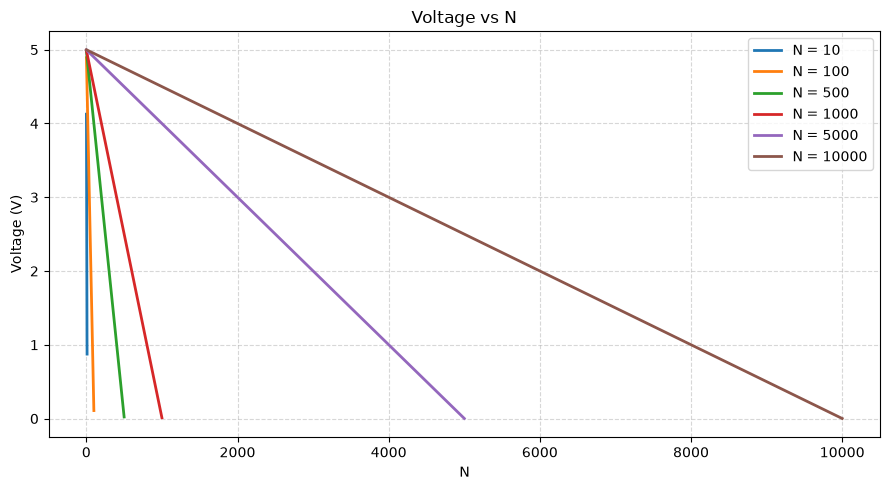

In [39]:
plt.figure(figsize=(9, 5))

for n_nodes in N_values:
  A_temp = np.zeros((5, n_nodes))
  A_temp[2, :] = 4
  A_temp[2, 0] = 3
  A_temp[2, -1] = 3
  A_temp[1, 1:] = -1
  A_temp[3, :-1] = -1
  A_temp[0, 2:] = -1
  A_temp[4, :-2] = -1

  w_temp = np.zeros(n_nodes)
  w_temp[0] = 5
  w_temp[1] = 5

  v_sol = banded(A_temp, w_temp, 2, 2)

  
  pos = np.arange(1, n_nodes + 1)
  plt.plot(pos, v_sol, label=f"N = {n_nodes}", linewidth=2)

plt.title("Voltage vs N")
plt.xlabel("N")
plt.ylabel("Voltage (V)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig('V_vs_n.png')
plt.show()

#### Problem 1 code summary
Solving the system of linear equations derived from Kirchhoff's laws yields the node voltages across the resistor ladder for $N = 10, 100, 500, 1000, 5000,$ and $10,000$ junctions. To optimize efficiency for large $N$, the coefficient matrix is stored in a 5-diagonal banded function and solved using Newman's banded Gaussian elimination algorithm. 

---

## Section 3 (Notes)

### Some codes for solving matrix problems

* solving matrix equations ($\bf{A}\vec{x} = \vec{b}$) -> `np.linalg.solve`
* LU-decomposition ($\bf{A} = \bf{L}\bf{U}$) -> `scipy.linalg.lu`
* matrix inversion ($\bf{A}^{-1}$) -> `np.linalg.inv`
* QR-decomposition ($\bf{A} = \bf{Q}\bf{R}$) -> `scipy.linalg.qr`
* eigenvalue problem ($\bf{A}\vec{x} = \lambda \vec{x}$) -> `np.linalg.eig`

Solving matrix problems by themselves isn't difficult. There is an abundance of linear algebra libraries that are ready to use: from the battle-tested ones (the classic [BLAS](https://www.netlib.org/blas/) and [LAPACK](https://www.netlib.org/lapack/)), HPC tools for large problems ([ScaLAPACK](https://netlib.org/scalapack/)), to hardware-accelerated ones often with GPUs ([cuBLAS](https://docs.nvidia.com/cuda/cublas/index.html) and [cuSolver](https://docs.nvidia.com/cuda/cusolver/index.html) for NVIDIA). 

The hardest part is actually composing the matrix. How do you transform a physical problem into a linear algebra problem?

* Circuit: https://personal.math.vt.edu/embree/cmda3606/chapter2.pdf
* Embree [main notes](https://personal.math.vt.edu/embree/cmda3606notes.pdf) + [lab manual](https://personal.math.vt.edu/embree/labman.pdf)

#### Sample Usage

### Importing functions from a python file

In [6]:
import samplePackage as sP

In [7]:
sP.createZerosArray(4,5)

array([[0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.]])